In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field

RENAME_MAP = {
    " m³/m³ Water Content": "soil_water",
    " °C Soil Temperature": "soil_temp",
    " min Leaf Wetness": "leaf_wet_min",
    " W/m² Solar Radiation": "solar_rad",
    " mm Precipitation": "precip",
    "° Wind Direction": "wind_dir",
    " m/s Wind Speed": "wind_speed",
    " m/s Gust Speed": "gust_speed",
    " °C Air Temperature": "air_temp",
    " RH Relative Humidity": "rh",
    " kPa Atmospheric Pressure": "pressure",
    " mm/h Max Precip Rate": "max_precip_rate",
}
GDD_BASE_C = 10.0


def load_hourly(path):
    df = pd.read_excel(path, index_col=0)
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df = df[list(RENAME_MAP)].rename(columns=RENAME_MAP)
    df[["wind_dir", "wind_speed", "gust_speed"]] = (
        df[["wind_dir", "wind_speed", "gust_speed"]].interpolate("time")
    )
    return df


def _saturation_vp(temp_c):
    return 0.6108 * np.exp(17.27 * temp_c / (temp_c + 237.3))


def to_daily(hourly, derived=True):
    r = hourly.resample("D")
    theta = np.deg2rad(hourly["wind_dir"])
    out = pd.DataFrame(
        {
            "air_temp_mean": r["air_temp"].mean(),
            "air_temp_min": r["air_temp"].min(),
            "air_temp_max": r["air_temp"].max(),
            "soil_temp_mean": r["soil_temp"].mean(),
            "soil_temp_min": r["soil_temp"].min(),
            "soil_temp_max": r["soil_temp"].max(),
            "rh_mean": r["rh"].mean(),
            "rh_min": r["rh"].min(),
            "rh_max": r["rh"].max(),
            "solar_rad_sum": r["solar_rad"].sum(),
            "solar_rad_mean": r["solar_rad"].mean(),
            "precip_sum": r["precip"].sum(),
            "max_precip_rate": r["max_precip_rate"].max(),
            "wind_speed_mean": r["wind_speed"].mean(),
            "gust_speed_max": r["gust_speed"].max(),
            "wind_dir_sin": np.sin(theta).resample("D").mean(),
            "wind_dir_cos": np.cos(theta).resample("D").mean(),
            "soil_water_mean": r["soil_water"].mean(),
            "leaf_wet_min_sum": r["leaf_wet_min"].sum(),
        }
    )
    if derived:
        out["gdd"] = ((out["air_temp_max"] + out["air_temp_min"]) / 2 - GDD_BASE_C).clip(lower=0)
        out["vpd"] = _saturation_vp(out["air_temp_mean"]) * (1 - out["rh_mean"])
        out["leaf_wet_hours"] = out["leaf_wet_min_sum"] / 60.0
    return out


@dataclass
class WeatherSequences:
    dates: list
    feature_cols: list
    sequences: dict
    date_to_idx: dict = field(init=False)

    def __post_init__(self):
        self.date_to_idx = {d: i for i, d in enumerate(self.dates)}

    @property
    def lengths(self):
        return np.array([len(self.sequences[d]) for d in self.dates], dtype=np.int64)

    @property
    def n_features(self):
        return len(self.feature_cols)

    def padded_bank(self):
        max_len = int(self.lengths.max())
        bank = np.zeros((len(self.dates), max_len, self.n_features), dtype=np.float32)
        for i, d in enumerate(self.dates):
            seq = self.sequences[d]
            bank[i, : len(seq)] = seq
        return bank, self.lengths


def build_sequences(daily, flight_dates, feature_cols=None, season_start=None):
    if feature_cols is None:
        feature_cols = list(daily.columns)
    dates = sorted(pd.to_datetime(pd.Index(flight_dates)).normalize().unique())
    start = pd.Timestamp(season_start) if season_start is not None else daily.index.min()
    mat = daily[feature_cols]
    sequences = {d: mat.loc[start:d].to_numpy(dtype=np.float32) for d in dates}
    return WeatherSequences(dates=list(dates), feature_cols=feature_cols, sequences=sequences)

In [2]:
hourly = load_hourly("../Data/PPAC-B3/2021/PPAC_B3_2021_weather.xlsx")
print(hourly.shape, "hourly rows |", hourly.index.min(), "->", hourly.index.max())
hourly.head()

(1824, 12) hourly rows | 2021-06-24 00:00:00 -> 2021-09-07 23:00:00


,soil_water,soil_temp,leaf_wet_min,solar_rad,precip,wind_dir,wind_speed,gust_speed,air_temp,rh,pressure,max_precip_rate
Timestamp,,,,,,,,,,,,
2021-06-24 00:00:00,0.264685,21.45,0,0.0,0.0,169.0,2.26,4.44,18.27,0.686972,99.02,0.0
2021-06-24 01:00:00,0.264724,21.01,0,0.0,0.0,165.0,2.39,4.66,17.93,0.696449,99.04,0.0
2021-06-24 02:00:00,0.264840,20.62,0,0.0,0.0,173.0,2.44,5.03,17.67,0.702997,99.06,0.0
2021-06-24 03:00:00,0.264840,20.28,0,0.0,0.0,171.0,2.21,4.33,17.04,0.719704,99.08,0.0
2021-06-24 04:00:00,0.264879,19.98,0,0.0,0.0,167.0,2.24,4.39,16.65,0.740376,99.08,0.0


In [3]:
daily = to_daily(hourly)
print(daily.shape, "daily rows |", daily.isna().sum().sum(), "NaNs")
daily.to_csv("../Data/PPAC-B3/2021/PPAC_B3_2021_weather_daily.csv")
daily.head()

(76, 22) daily rows | 0 NaNs


,air_temp_mean,air_temp_min,air_temp_max,soil_temp_mean,soil_temp_min,soil_temp_max,rh_mean,rh_min,rh_max,solar_rad_sum,...,max_precip_rate,wind_speed_mean,gust_speed_max,wind_dir_sin,wind_dir_cos,soil_water_mean,leaf_wet_min_sum,gdd,vpd,leaf_wet_hours
Timestamp,,,,,,,,,,,,,,,,,,,,,
2021-06-24,20.146250,15.37,26.05,21.260833,19.00,23.52,0.756789,0.570684,0.944721,3452.2,...,9.178723,2.805417,10.89,0.061063,-0.893010,0.262702,405,10.710,0.573865,6.750000
2021-06-25,21.862083,19.48,24.86,21.847083,20.70,23.40,0.944995,0.882910,0.995739,2039.9,...,67.319149,2.687083,10.27,-0.233091,-0.886930,0.313226,1095,12.170,0.144212,18.250000
2021-06-26,23.116667,20.90,27.45,23.204583,21.80,25.17,0.942718,0.803775,0.993871,2964.5,...,118.319149,3.681250,12.94,-0.443335,-0.848817,0.374713,1297,14.175,0.162068,21.616667
2021-06-27,24.642083,22.07,28.44,24.316667,22.40,27.64,0.864361,0.708620,0.944337,5236.2,...,0.000000,3.196250,10.46,-0.578761,-0.544087,0.359600,681,15.255,0.420597,11.350000
2021-06-28,22.900000,20.17,28.19,25.086667,22.98,28.00,0.937924,0.800418,0.994849,4421.6,...,73.438298,1.351667,8.74,0.029022,-0.394176,0.342942,984,14.180,0.173347,16.400000


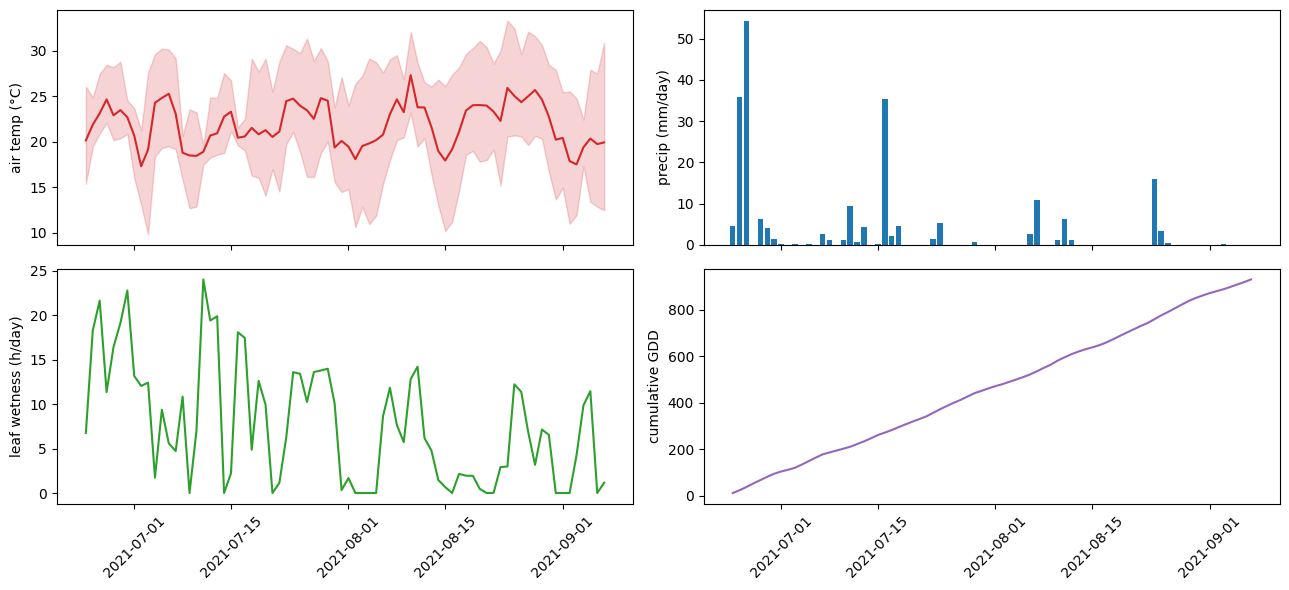

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 6), sharex=True)
axes[0, 0].plot(daily.index, daily["air_temp_mean"], color="tab:red")
axes[0, 0].fill_between(daily.index, daily["air_temp_min"], daily["air_temp_max"], alpha=0.2, color="tab:red")
axes[0, 0].set_ylabel("air temp (°C)")
axes[0, 1].bar(daily.index, daily["precip_sum"], color="tab:blue")
axes[0, 1].set_ylabel("precip (mm/day)")
axes[1, 0].plot(daily.index, daily["leaf_wet_hours"], color="tab:green")
axes[1, 0].set_ylabel("leaf wetness (h/day)")
axes[1, 1].plot(daily.index, daily["gdd"].cumsum(), color="tab:purple")
axes[1, 1].set_ylabel("cumulative GDD")
for ax in axes.flat:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [5]:
vi = pd.read_excel("../combined_vi_stats_with_disease_PPAC-B3_2021.xlsx")
flight_dates = pd.to_datetime(vi["DATE"], format="%m%d%Y").unique()

seqs = build_sequences(daily, flight_dates)
print(f"{len(seqs.dates)} flight dates | F={seqs.n_features} weather features")
for d, L in zip(seqs.dates, seqs.lengths):
    print(f"  {d.date()}  seq_len={L}")

bank, lengths = seqs.padded_bank()
print("padded bank:", bank.shape, "| lengths:", lengths.tolist())

11 flight dates | F=22 weather features
  2021-06-24  seq_len=1
  2021-07-01  seq_len=8
  2021-07-09  seq_len=16
  2021-07-14  seq_len=21
  2021-07-30  seq_len=37
  2021-08-04  seq_len=42
  2021-08-13  seq_len=51
  2021-08-17  seq_len=55
  2021-08-25  seq_len=63
  2021-08-31  seq_len=69
  2021-09-07  seq_len=76
padded bank: (11, 76, 22) | lengths: [1, 8, 16, 21, 37, 42, 51, 55, 63, 69, 76]


In [6]:
bank

array([[[20.14625   , 15.37      , 26.05      , ..., 10.71      ,
          0.5738645 ,  6.75      ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ]],

       [[20.14625   , 15.37      , 26.05      , ..., 10.71      ,
          0.5738645 ,  6.75      ],
        [21.862083  , 19.48      , 24.86      , ..., 12.17      ,
          0.14421217, 18.25      ],
        [23.116667  , 20.9       , 27.45      , ..., 14.175     ,
          0.16206826, 21.616667  ],
        ...,
        [ 0.        ,  0.        ,  0.        , ...,  